# ***Exoplanet Detection*** ***Notebook***


# **FOR DATASET 1:**

Processing Dataset 1: KIC 6922244


/usr/local/lib/python3.10/dist-packages/lightkurve/search.py:424: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


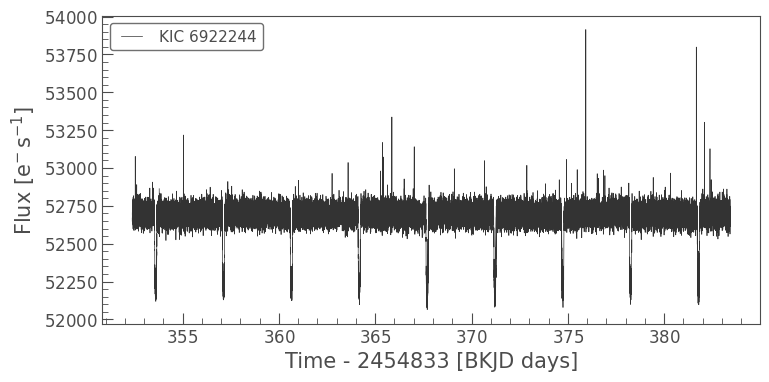

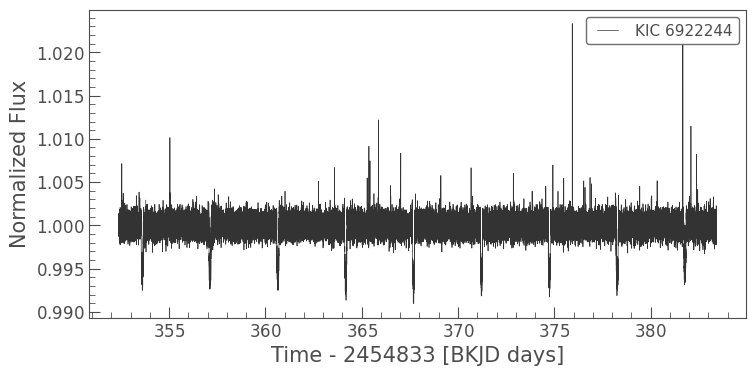

Detected orbital period for Dataset 1: 1.76 days
Transit duration for Dataset 1: 29.39 hours
Radius ratio for Dataset 1: 10.17


In [7]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

# Helper function to calculate the radius ratio
def calculate_radius_ratio(stellar_radius, planetary_radius):
    return stellar_radius / (planetary_radius * 0.10045)  # Convert planetary radius from Jupiter radii to Solar radii

# Helper function to estimate transit duration
def estimate_transit_duration(lightcurve, period):
    folded_lc = lightcurve.fold(period=period)  # Fold light curve by the orbital period
    folded_time = folded_lc.time.value  # Extract folded time values
    folded_flux = folded_lc.flux.value  # Extract folded flux values

    # Handle NaN values in folded_flux
    folded_flux = np.nan_to_num(folded_flux)  # Convert NaNs to 0 or a safe value

    # Identify the in-transit points (flux significantly lower than the baseline)
    baseline_flux = np.median(folded_flux)  # Calculate the baseline flux
    in_transit = (folded_flux < baseline_flux - 0.01)  # Consider flux < baseline - 1% as in transit

    # Check if there are any in-transit points
    if np.sum(in_transit) == 0:
        print("No clear transit detected in the light curve.")
        return None  # Return None or a default value if no transit points are found

    # Calculate the transit duration: time between the first and last in-transit points
    transit_duration = folded_time[in_transit][-1] - folded_time[in_transit][0]

    # Return transit duration in hours
    return transit_duration * 24  # Convert days to hours

# Dataset 1: KIC 6922244 (Kepler, 4th Quarter)
print("Processing Dataset 1: KIC 6922244")
lc_kic = lk.search_lightcurve("KIC 6922244", mission="Kepler", quarter=4).download()
stellar_radius_kic = 1.45  # Stellar radius in Solar radii (Kepler-8)
planetary_radius_kic = 1.419  # Planet radius in Jupiter radii (Kepler-8b)

# Plot raw light curve
lc_kic.plot(title="KIC 6922244 Raw Light Curve")
plt.show()

# Flatten and detrend light curve
lc_kic_flat = lc_kic.flatten()
lc_kic_flat.plot(title="KIC 6922244 Detrended Light Curve")
plt.show()

# Periodogram to detect periodic signals
periodogram_kic = lc_kic_flat.to_periodogram(method="lombscargle")
period_kic = periodogram_kic.period_at_max_power.value  # Orbital period in days
print(f"Detected orbital period for Dataset 1: {period_kic:.2f} days")

# Transit duration
transit_duration_kic = estimate_transit_duration(lc_kic_flat, period_kic)
if transit_duration_kic is not None:
    print(f"Transit duration for Dataset 1: {transit_duration_kic:.2f} hours")

# Radius ratio
radius_ratio_kic = calculate_radius_ratio(stellar_radius_kic, planetary_radius_kic)
print(f"Radius ratio for Dataset 1: {radius_ratio_kic:.2f}")






# **FOR DATASET 2 :**


Processing Dataset 2: Pi Mensae


/usr/local/lib/python3.10/dist-packages/lightkurve/search.py:424: LightkurveWarning: Warning: 7 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


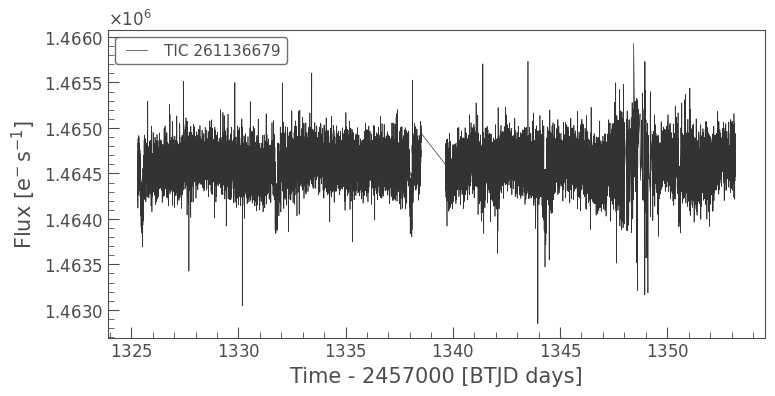

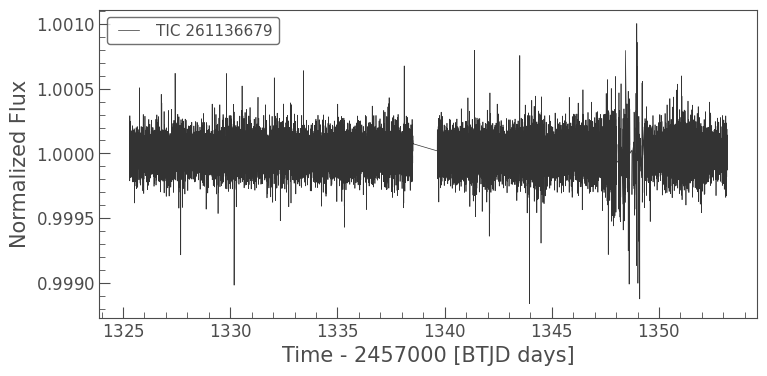

Detected orbital period for Dataset 2: 0.08 days
No clear transit detected in the light curve.
Radius ratio for Dataset 2: 5.76


In [8]:
# Dataset 2: Pi Mensae (TESS, Sector 1)
print("\nProcessing Dataset 2: Pi Mensae")
lc_pim = lk.search_lightcurve("Pi Mensae", mission="TESS", sector=1).download()
stellar_radius_pim = 1.1  # Stellar radius in Solar radii (Pi Mensae)
planetary_radius_pim = 1.9  # Planet radius in Jupiter radii (Pi Mensae b)

# Plot raw light curve
lc_pim.plot(title="Pi Mensae Raw Light Curve")
plt.show()

# Flatten and detrend light curve
lc_pim_flat = lc_pim.flatten()
lc_pim_flat.plot(title="Pi Mensae Detrended Light Curve")
plt.show()

# Periodogram to detect periodic signals
periodogram_pim = lc_pim_flat.to_periodogram(method="lombscargle")
period_pim = periodogram_pim.period_at_max_power.value  # Orbital period in days
print(f"Detected orbital period for Dataset 2: {period_pim:.2f} days")

# Transit duration
transit_duration_pim = estimate_transit_duration(lc_pim_flat, period_pim)
if transit_duration_pim is not None:
    print(f"Transit duration for Dataset 2: {transit_duration_pim:.2f} hours")

# Radius ratio
radius_ratio_pim = calculate_radius_ratio(stellar_radius_pim, planetary_radius_pim)
print(f"Radius ratio for Dataset 2: {radius_ratio_pim:.2f}")